In [1]:
import os
import random
import re
import sys

import numpy as np
import cv2

sys.path.append(os.path.join("..", "src"))
from data import load_images
from preprocess import preprocess_image
from augment import augment_train_set
from eval_utils import plot_learning_curve, plot_sample_predictions

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# **[1] Load Data**

In [3]:
DATA_DIR = os.path.join("..", "data", "images")

images_train, y_train_label, paths_train = load_images(os.path.join(DATA_DIR, "train"))
images_test, y_test_label, paths_test = load_images(os.path.join(DATA_DIR, "test"))

print(f"Train: {len(images_train)}, Test: {len(images_test)}")
print(f"Kelas: {sorted(set(y_train_label))}")

Train: 417, Test: 195
Kelas: ['damba', 'faiq', 'faqih']


#### Preview Data (Sebelum Preprocessing)

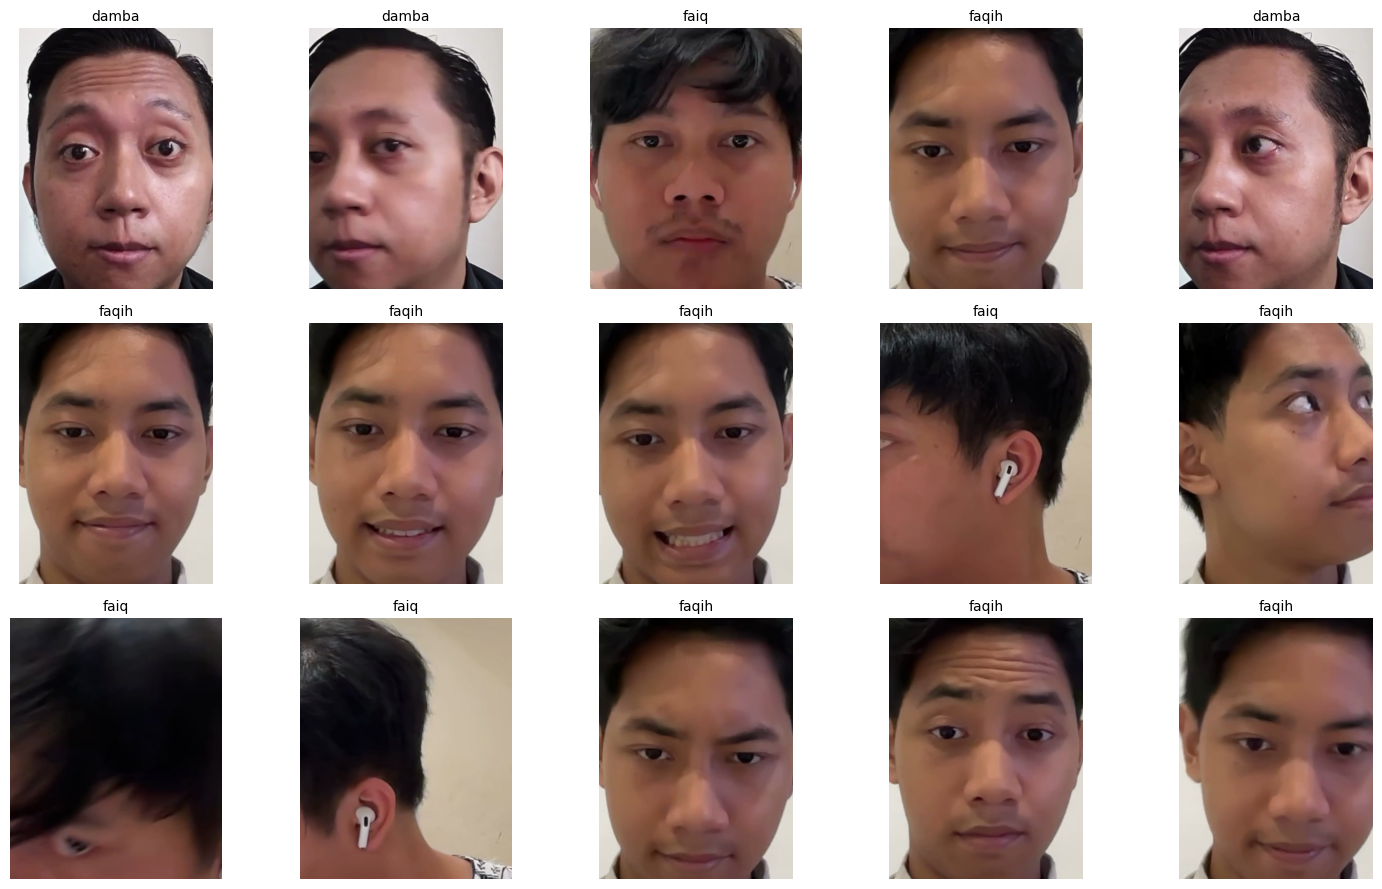

In [4]:
rng = np.random.default_rng(SEED)
preview_indices = rng.choice(len(images_train), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, idx in zip(axes.flatten(), preview_indices):
    ax.imshow(cv2.cvtColor(images_train[idx], cv2.COLOR_BGR2RGB))
    ax.axis("off")
    ax.set_title(y_train_label[idx], fontsize=10)

plt.tight_layout()
plt.show()

#### Train/Val Split (Temporal, per anggota)

In [5]:
VAL_RATIO = 0.15
VAL_GAP = 5  # frame dibuang di titik potong biar train/val gak near-duplicate


def _frame_index(path):
    match = re.search(r"_(\d+)\.\w+$", os.path.basename(path))
    return int(match.group(1)) if match else -1


train_idx, val_idx = [], []
for member_name in sorted(set(y_train_label)):
    member_indices = [i for i, label in enumerate(y_train_label) if label == member_name]
    member_indices.sort(key=lambda i: _frame_index(paths_train[i]))

    split_idx = int(len(member_indices) * (1 - VAL_RATIO))
    train_idx.extend(member_indices[:max(split_idx - VAL_GAP, 0)])
    val_idx.extend(member_indices[split_idx + VAL_GAP:])

train_idx = np.array(sorted(train_idx))
val_idx = np.array(sorted(val_idx))

images_val = [images_train[i] for i in val_idx]
y_val_label, paths_val = y_train_label[val_idx], paths_train[val_idx]

images_train = [images_train[i] for i in train_idx]
y_train_label, paths_train = y_train_label[train_idx], paths_train[train_idx]

print(f"Train: {len(images_train)}, Val: {len(images_val)}")

Train: 338, Val: 49


# **[2] Preprocessing**

#### Grayscale & Resize

In [6]:
IMAGE_SIZE = (224, 224)


def reshape_images(images):
    processed = [preprocess_image(image, IMAGE_SIZE) for image in images]
    return np.expand_dims(np.array(processed, dtype=np.float32) / 255.0, axis=-1)


X_train = reshape_images(images_train)
X_val = reshape_images(images_val)
X_test = reshape_images(images_test)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}, Shape per data: {X_train.shape[1:]}")

Train: 338, Val: 49, Test: 195, Shape per data: (224, 224, 1)


#### Augmentasi Data (Train Only)

In [7]:
images_train_aug, y_train_label_aug, paths_train_aug = augment_train_set(paths_train, y_train_label)

X_train_aug = np.expand_dims(np.array(images_train_aug, dtype=np.float32) / 255.0, axis=-1)

X_train = np.concatenate([X_train, X_train_aug], axis=0)
y_train_label = np.concatenate([y_train_label, y_train_label_aug], axis=0)
paths_train = np.concatenate([paths_train, paths_train_aug], axis=0)

print(f"Train setelah augmentasi: {X_train.shape[0]} data")

Train setelah augmentasi: 2366 data


#### Preview Data (Setelah Augmentasi)

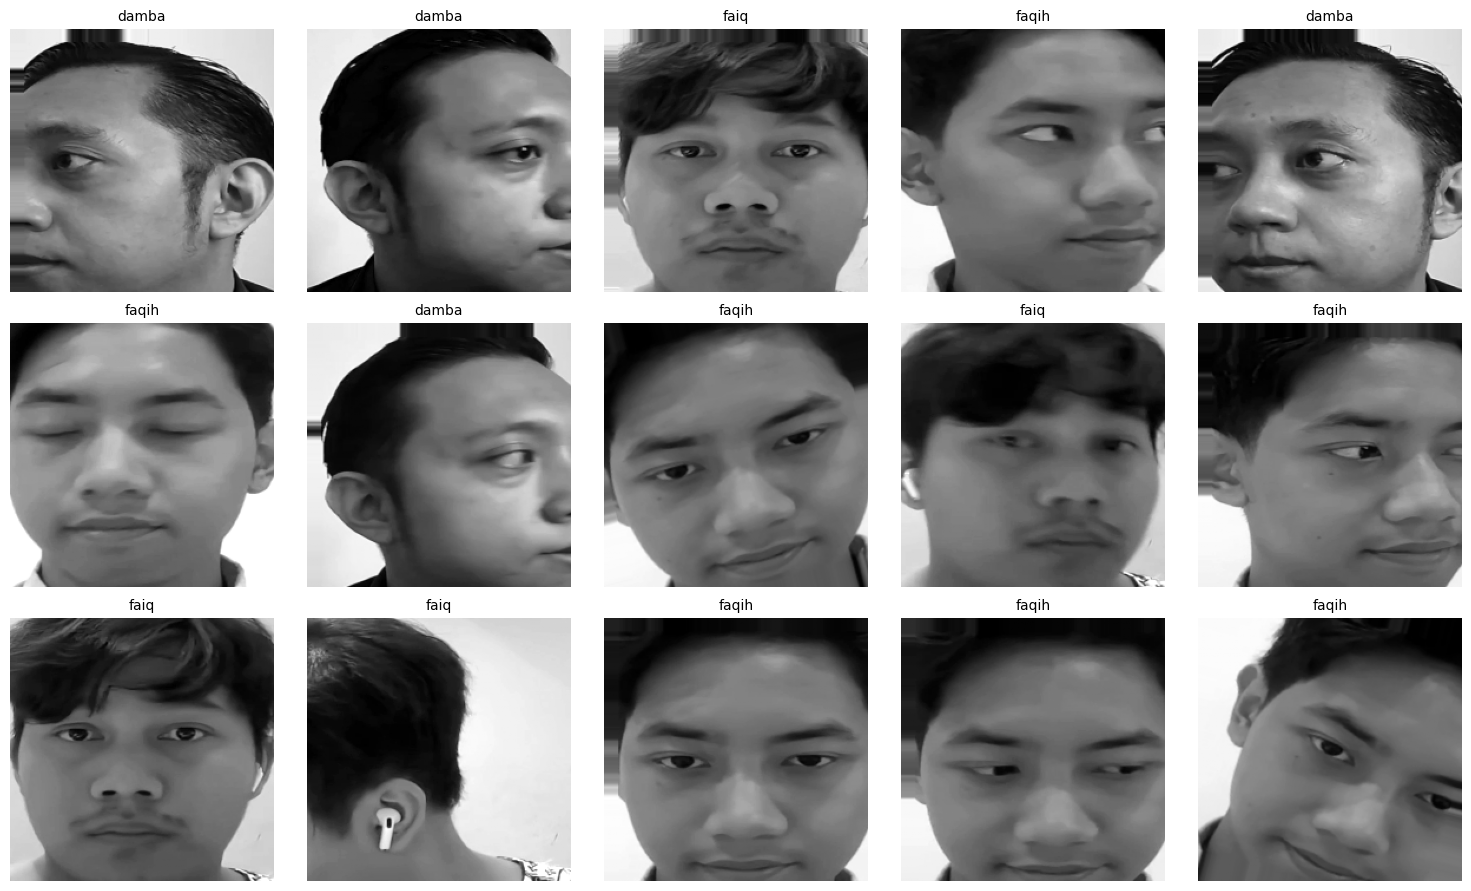

In [8]:
rng = np.random.default_rng(SEED)
aug_preview_idx = rng.choice(len(images_train_aug), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, idx in zip(axes.flatten(), aug_preview_idx):
    ax.imshow(images_train_aug[idx], cmap="gray")
    ax.axis("off")
    ax.set_title(y_train_label_aug[idx], fontsize=10)

plt.tight_layout()
plt.show()

#### Encoding

In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train_label)

y_train = to_categorical(label_encoder.transform(y_train_label))
y_val = to_categorical(label_encoder.transform(y_val_label))
y_test = to_categorical(label_encoder.transform(y_test_label))

num_classes = y_train.shape[1]
input_shape = X_train.shape[1:]

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(label_encoder.transform(y_train_label)),
    y=label_encoder.transform(y_train_label)
)
class_weight_dict = dict(enumerate(class_weight_values))

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Class weight: {class_weight_dict}")

Train: 2366, Val: 49, Test: 195
Class weight: {0: 0.9388888888888889, 1: 1.073015873015873, 2: 0.9970501474926253}


# **[3] Build Model**

In [10]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=[F1Score(average="macro", name="f1_score")]
)

model.summary()

/Users/faqihfirmanpratama/miniforge3/envs/dbs/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-24 17:13:49.386733: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-09-24 17:13:49.386757: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-09-24 17:13:49.386767: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-09-24 17:13:49.386781: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-24 17:13:49.386790: I tensorflow/core/common_runtime/pluggable_device/plu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,019 (398.51 KB)

 Trainable params: 101,571 (396.76 KB)

 Non-trainable params: 448 (1.75 KB)

### Training

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50


2026-09-24 17:13:52.217961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


148/148 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - f1_score: 0.8078 - loss: 0.5246 - val_f1_score: 0.1641 - val_loss: 3.4428
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - f1_score: 0.8651 - loss: 0.4095 - val_f1_score: 0.1641 - val_loss: 5.2580
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - f1_score: 0.8740 - loss: 0.4110 - val_f1_score: 0.1641 - val_loss: 6.1982
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - f1_score: 0.8965 - loss: 0.3611 - val_f1_score: 0.1641 - val_loss: 3.0665
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - f1_score: 0.9004 - loss: 0.3499 - val_f1_score: 0.7217 - val_loss: 0.6768
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - f1_score: 0.9195 - loss: 0.2637 - val_f1_score: 0.3308 - val_loss: 6.9416
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - f1_score: 0.9432 - loss: 0.1653 - val_f1_score: 0.9343 - val_loss: 0.2052
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - f1_score: 0.9595 - loss: 0.1219 - val_f1_sco

# **[4] Evaluation**

#### Learning Curve (F1 Score & Loss)

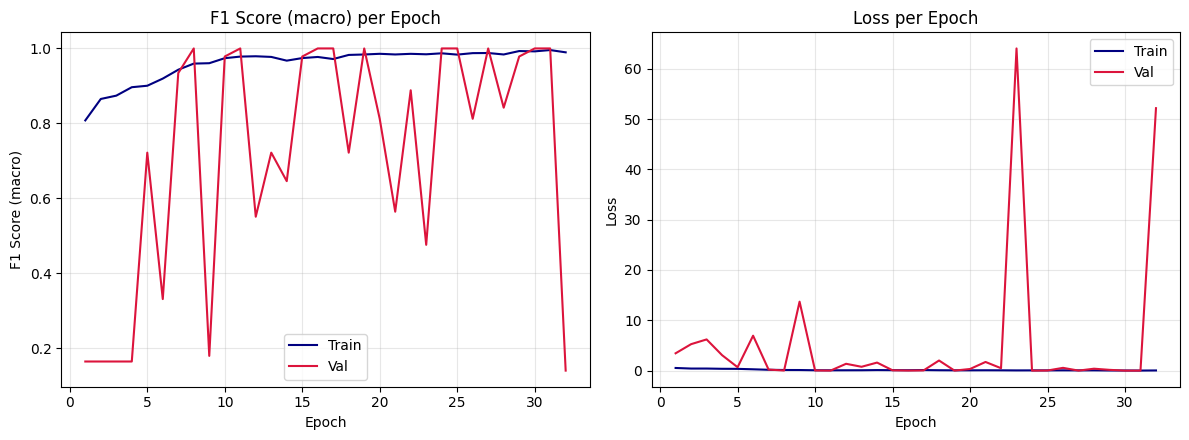

In [12]:
plot_learning_curve(history)

#### Evaluasi

              precision    recall  f1-score   support

       damba       0.77      1.00      0.87        96
        faiq       0.80      0.88      0.84        42
       faqih       0.83      0.35      0.49        57

    accuracy                           0.78       195
   macro avg       0.80      0.74      0.73       195
weighted avg       0.79      0.78      0.75       195



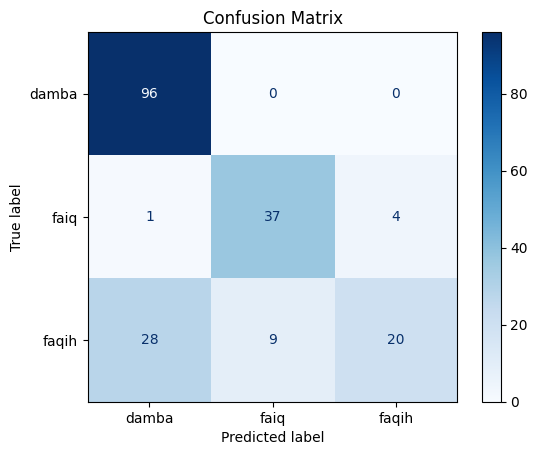

In [13]:
y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_test_true = np.argmax(y_test, axis=1)

print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))

confusion_mat = confusion_matrix(y_test_true, y_test_pred)
confusion_mat_display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=label_encoder.classes_)
confusion_mat_display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# **[5] Inference**

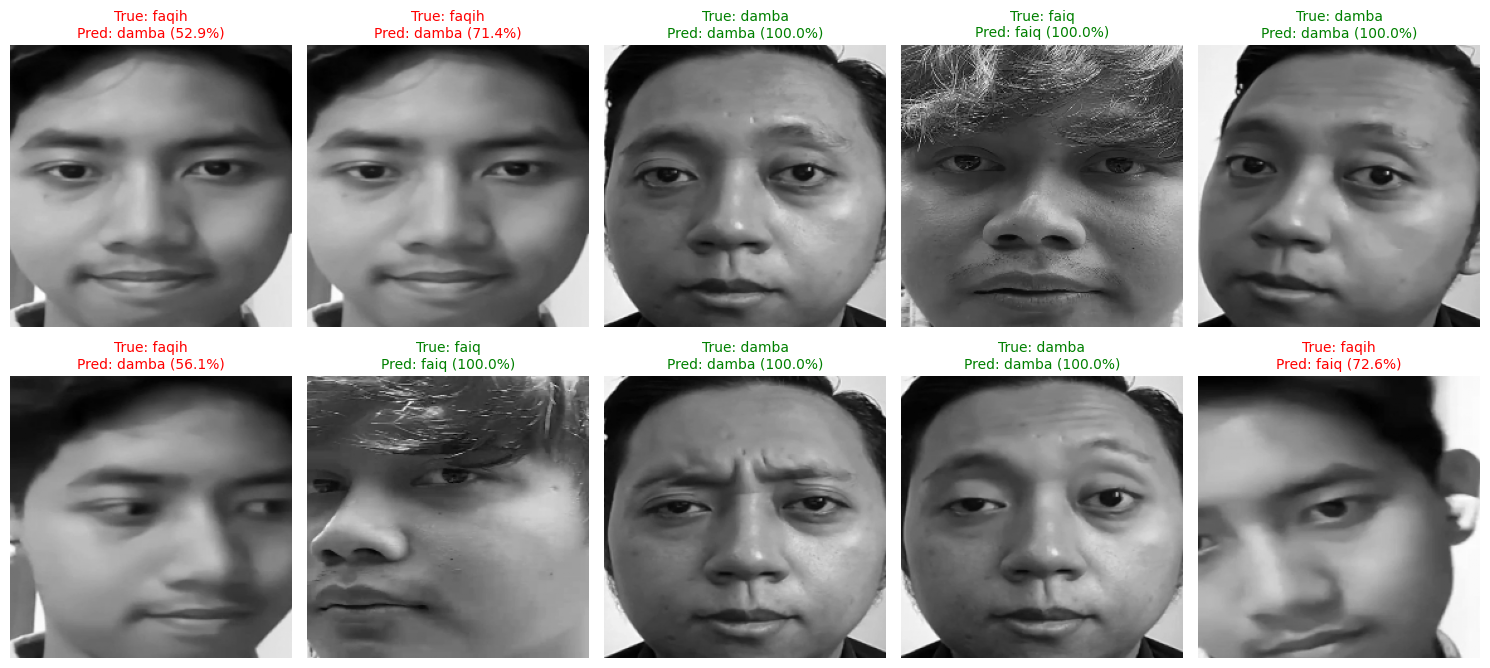

In [14]:
from preprocess import load_grayscale


def predict_image(model, image_path):
    image = load_grayscale(image_path)
    image_input = np.expand_dims(image.astype(np.float32) / 255.0, axis=(0, -1))

    prediction = model.predict(image_input, verbose=0)
    label = label_encoder.inverse_transform([np.argmax(prediction)])[0]
    confidence = np.max(prediction)
    return label, confidence, image


plot_sample_predictions(model, paths_test, y_test, label_encoder, predict_image, n_samples=10, seed=SEED)